In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy import stats
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn import metrics
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.utils.tools import seed_everything
import torch
from src.utils.constants import DEVICE



EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# sns.set_palette("colorblind")
# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]
palette=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=60)

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


In [3]:
targets=['bs','bf']
with open('benchmarks/DeepBurst_reg_task/results/bs_bf_para_reg_indicators.csv','w') as w:
    line = ['eid','fold','r','target']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:            
        for fold in [0,1,2,3]:
            checkpoints = f"benchmarks/DeepBurst_reg_task/checkpoints/{eid}.{fold}.bs_bf_para.reg.model.pt"
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            for target in targets:
                pearsonr = ckpt[f"{target}_val_r"]
                line = [eid,str(fold),str(pearsonr),target]
                w.write(','.join(line) + '\n')

data = pd.read_csv('benchmarks/DeepBurst_reg_task/results/bs_bf_para_reg_indicators.csv')
data['r'] = data['r'] / 100

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_18582/3810722000.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data[data['target']=='bf'],y='r',x='eid',fliersize=0, linewidth=0.3,order=order,
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_18582/3810722000.py:4: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=data[data['target']=='bf'],y='r',x='eid',fliersize=0, linewidth=0.3,order=order,
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_18582/3810722000.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([f"{EIDS_TO_CELLTYPES[eid]}" for eid in order])
No artists with labels found to put in lege

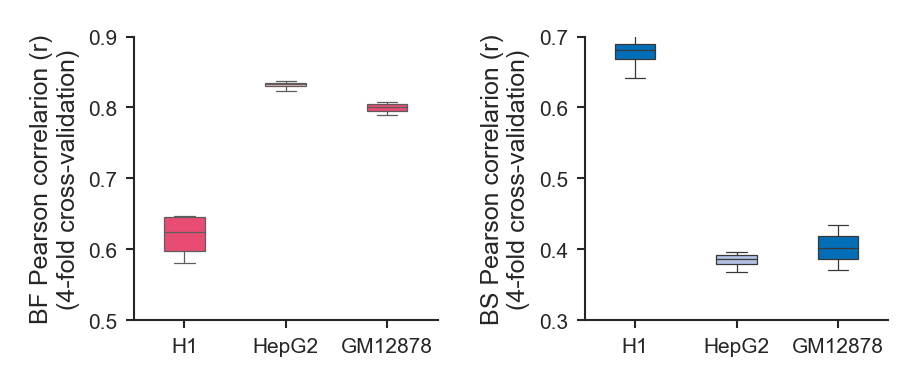

In [5]:


order = ['E003','E118','E116']
fig, ax = plt.subplots(1, 2, figsize=(8/2.54, 3.5/2.54))
palette = ['#E94C72',"#F6BEBB"]
sns.boxplot(data=data[data['target']=='bf'],y='r',x='eid',fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[0],saturation=1)

ax[0].set_xlabel("",fontsize=6)
ax[0].tick_params(axis='x', labelsize=5,width=0.5)
ax[0].tick_params(axis='y', labelsize=5,width=0.5)
ax[0].set_xticklabels([f"{EIDS_TO_CELLTYPES[eid]}" for eid in order])
ax[0].set_ylabel("BF Pearson correlarion (r)\n(4-fold cross-validation)",fontsize=6)
ax[0].legend().remove()

ax[0].set_ylim(0.5,0.9)
yticks = [i/100 for i in range(50,91,10)]
yticklabels = [f"{i:.1f}" for i in yticks]
ax[0].set_yticks(yticks, labels=yticklabels)


palette = ["#036EB8","#B2C1E3"]
sns.boxplot(data=data[data['target']=='bs'],y='r',x='eid', fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[1],saturation=1)

ax[1].set_xlabel("",fontsize=6)
ax[1].tick_params(axis='x', labelsize=5,width=0.5)
ax[1].tick_params(axis='y', labelsize=5,width=0.5)
ax[1].set_xticklabels([f"{EIDS_TO_CELLTYPES[eid]}" for eid in order])
ax[1].set_ylabel("BS Pearson correlarion (r)\n(4-fold cross-validation)",fontsize=6)
ax[1].legend().remove()
ax[1].set_ylim(0.3,0.7)
yticks = [i/100 for i in range(30,71,10)]
yticklabels = [f"{i:.1f}" for i in yticks]
ax[1].set_yticks(yticks, labels=yticklabels)

plt.tight_layout()
plt.savefig(f'benchmarks/DeepBurst_reg_task/figures/v6/Supplementary_Figure13C.eps', format='eps', bbox_inches='tight')
plt.show()